# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [122]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [123]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [124]:
import abc


class MSELoss(BaseLoss):
    """Базовый класс лосса"""

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float|None:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        if X.shape[1] != w.shape[0]:
            raise ValueError("Invalid X and w parameters given")
        ans = X@w
        if ans.shape[0] != y.shape[0]:
            raise ValueError("Invalid y size given")
        return np.mean((ans - y) ** 2).astype(float)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray|None:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        if l == 0:
            raise ZeroDivisionError("Object count equals zero")
        if X.shape[1] != w.shape[0]:
            raise ValueError("Invalid X and w parameters given")
        ans = X@w
        if ans.shape[0] != y.shape[0]:
            raise ValueError("Invalid y size given")
        return ((2 / l) * np.transpose(X) @ (ans - y)).astype(float)

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [125]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [ ]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    if w_init.shape[0] != X.shape[1]:
        raise ValueError("invalid X or w_init param given")
    w_current = w_init
    weights_hist = [w_current]
    for i in range(n_iterations):
        w_current = w_current - lr * loss.calc_grad(
            X = X,
            y = y,
            w = w_current
        )
        weights_hist.append(w_current)
    return weights_hist




Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [127]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [128]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450264
0.8670644395649493


In [129]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

0.0001


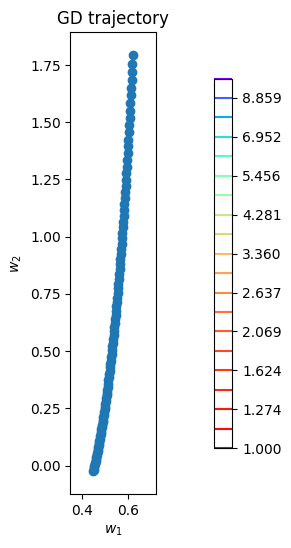

0.0021387755102040816


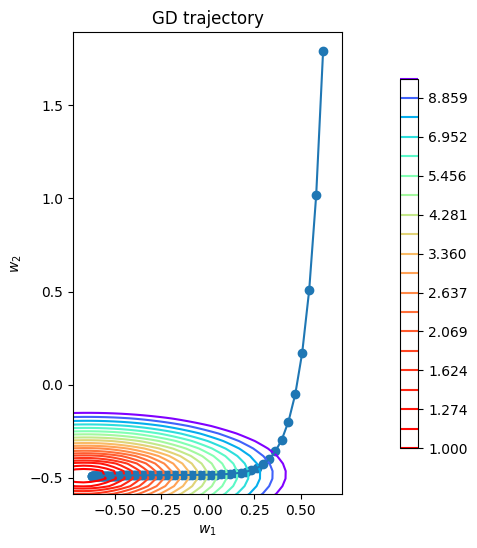

0.004177551020408164


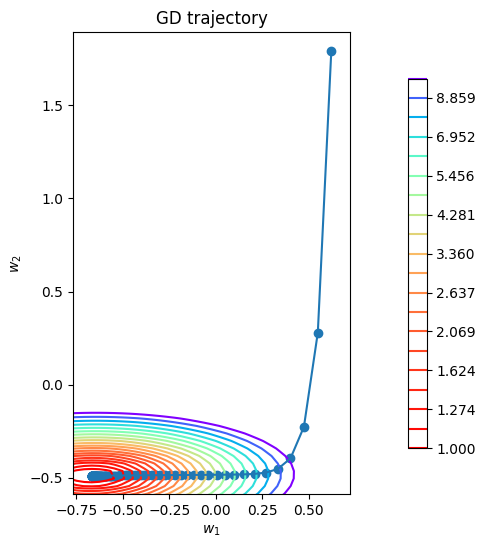

0.006216326530612245


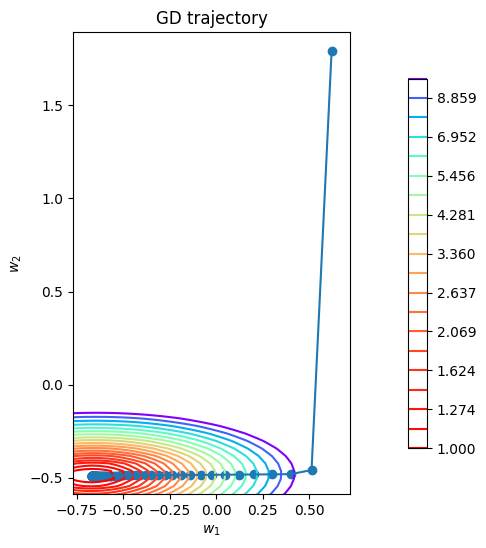

0.008255102040816326


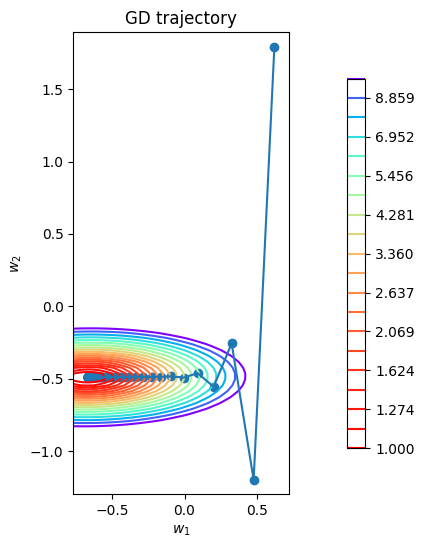

0.010293877551020408


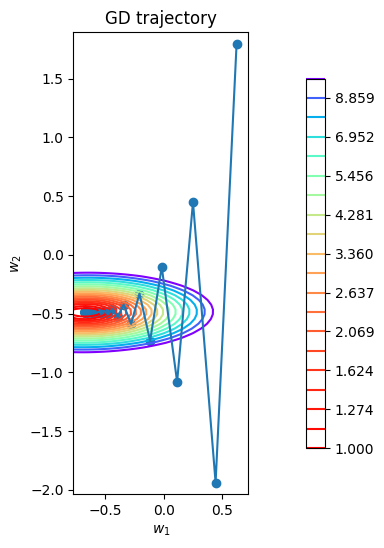

0.01233265306122449


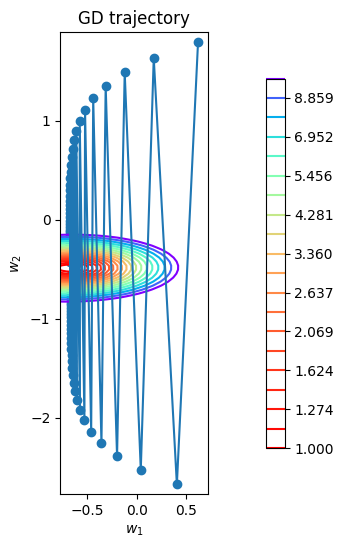

0.014371428571428571


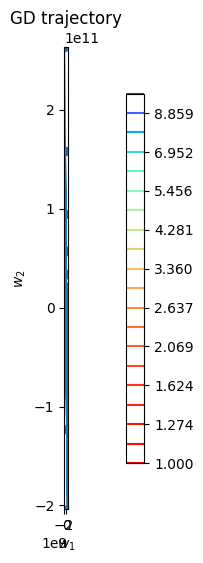

0.016410204081632653


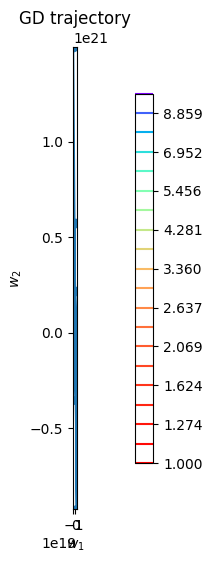

0.018448979591836733


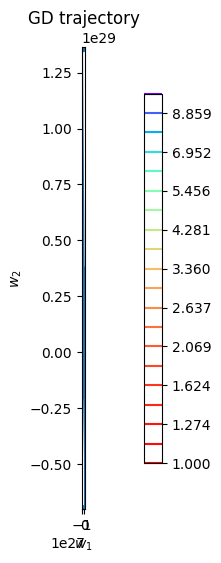

0.020487755102040817


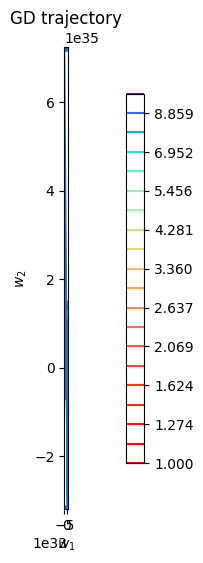

0.0225265306122449


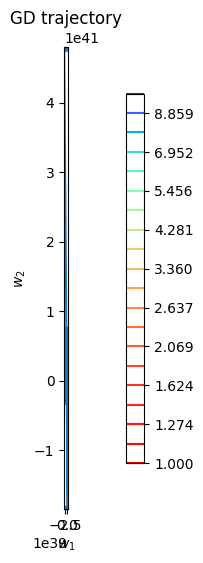

0.02456530612244898


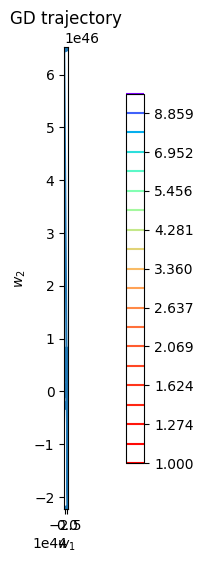

0.02660408163265306


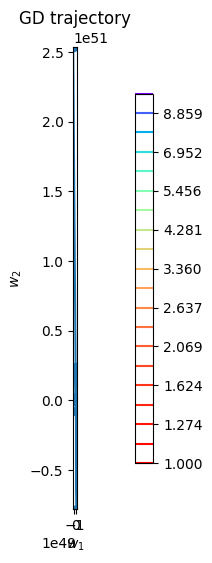

0.028642857142857144


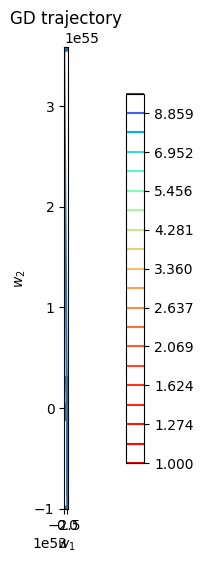

0.030681632653061227


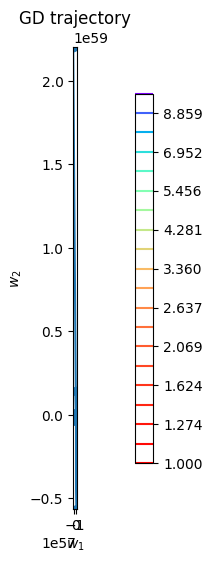

0.03272040816326531


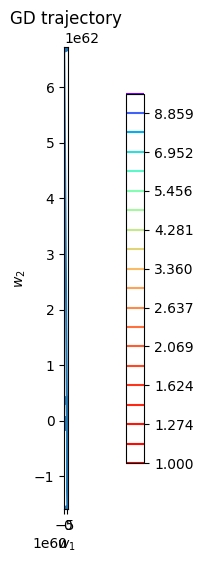

0.03475918367346939


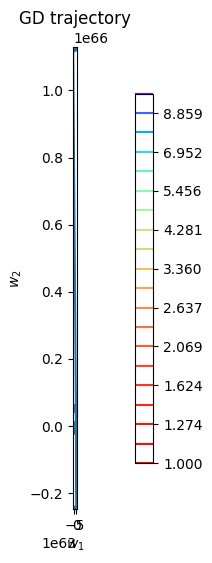

0.03679795918367347


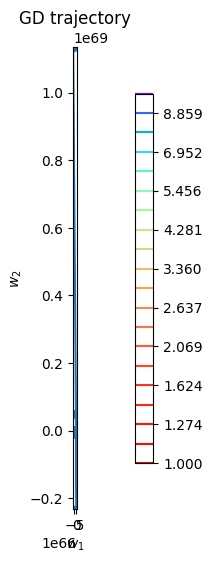

0.03883673469387756


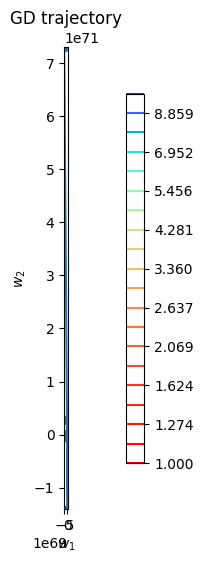

0.04087551020408164


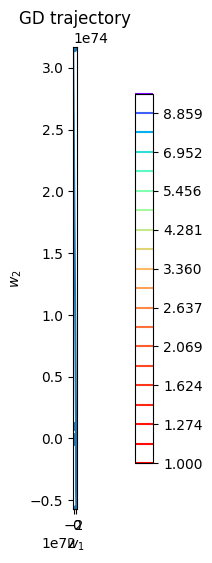

0.04291428571428572


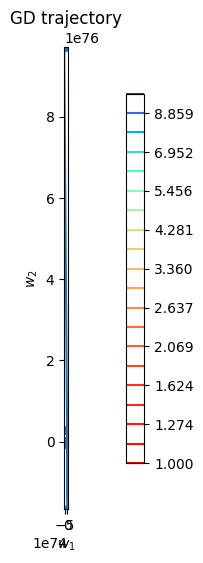

0.044953061224489804


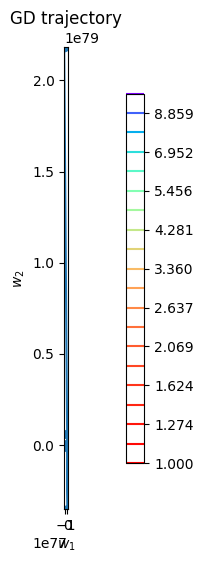

0.046991836734693884


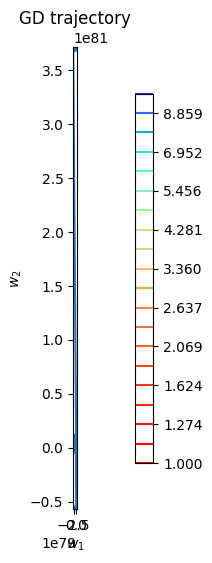

0.049030612244897964


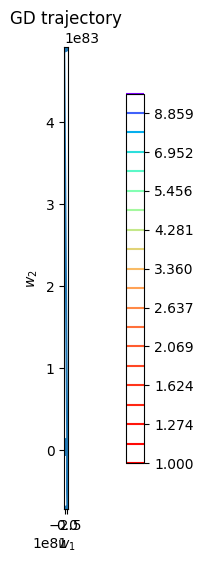

0.051069387755102044


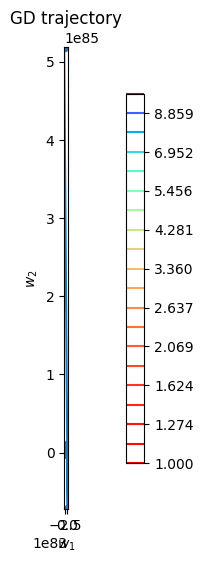

0.053108163265306124


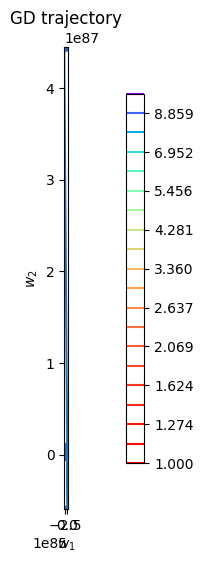

0.05514693877551021


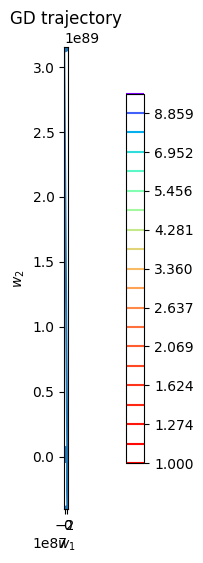

0.05718571428571429


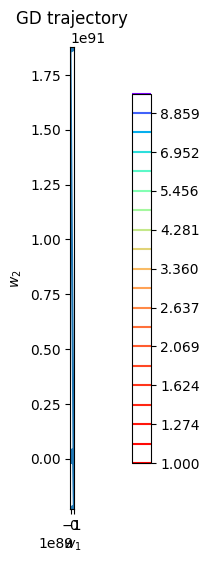

0.05922448979591837


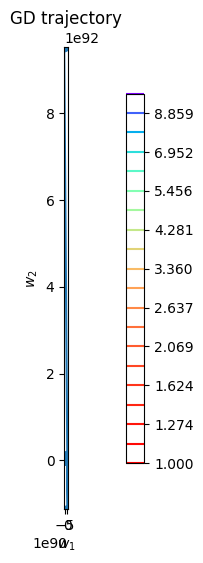

0.06126326530612246


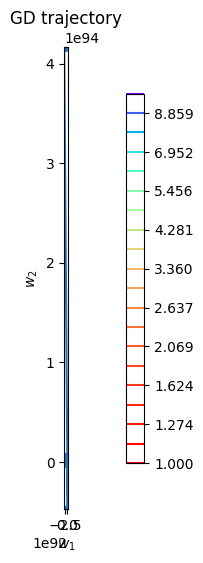

0.06330204081632654


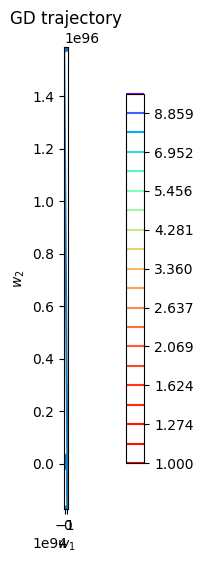

0.06534081632653062


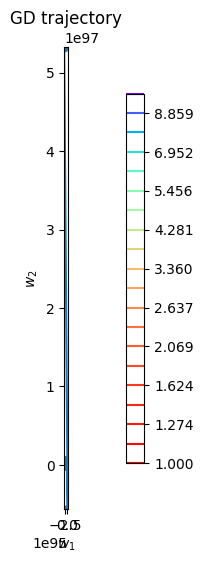

0.0673795918367347


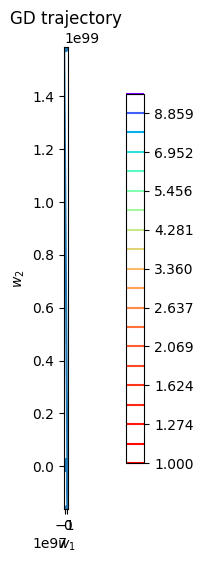

0.06941836734693878


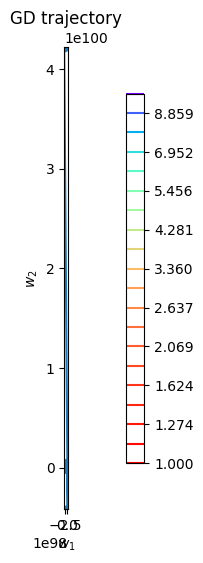

0.07145714285714286


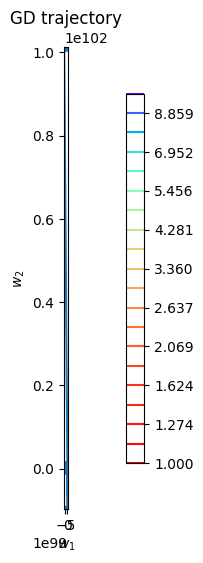

0.07349591836734694


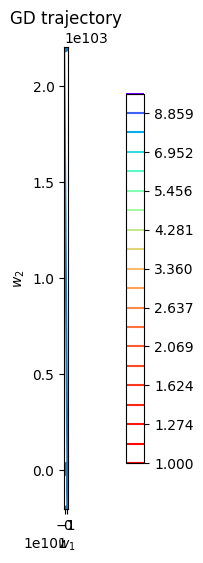

0.07553469387755103


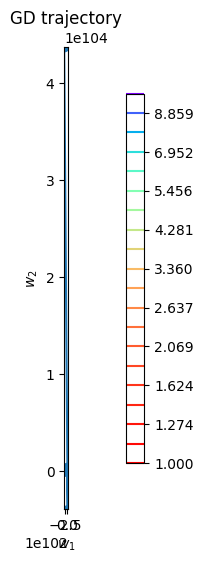

0.07757346938775511


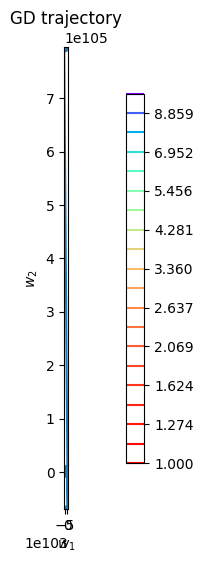

0.07961224489795919


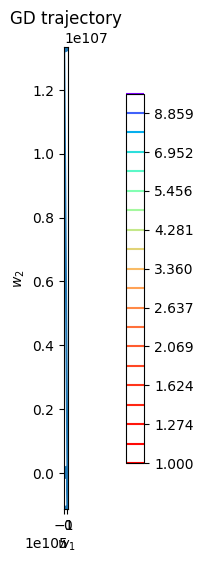

0.08165102040816327


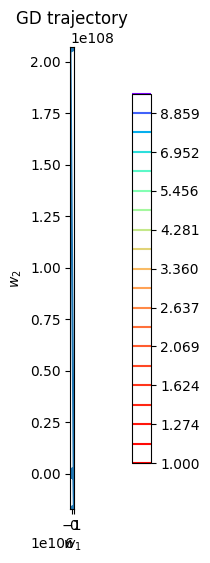

0.08368979591836735


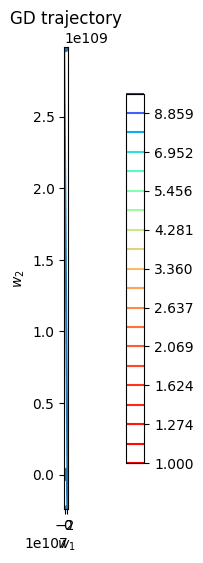

0.08572857142857143


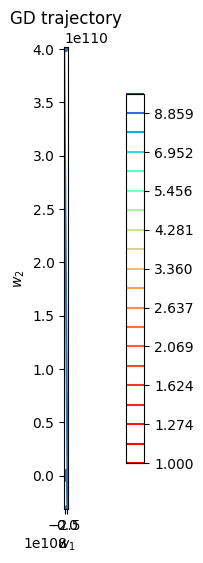

0.08776734693877551


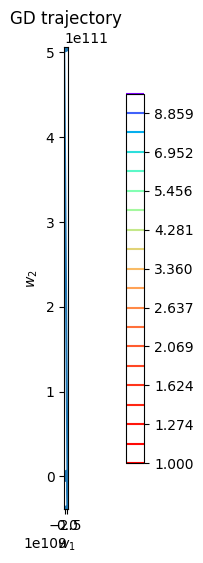

0.0898061224489796


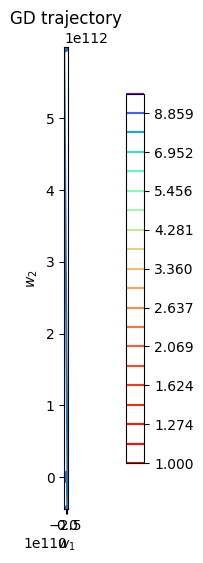

0.09184489795918369


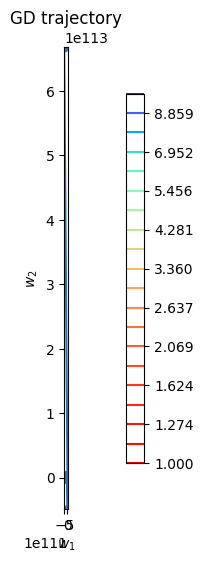

0.09388367346938777


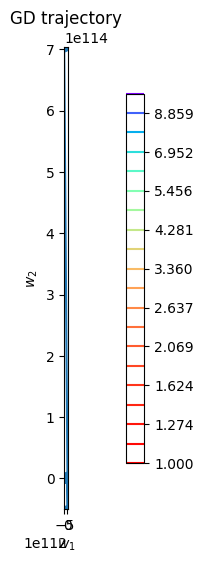

0.09592244897959185


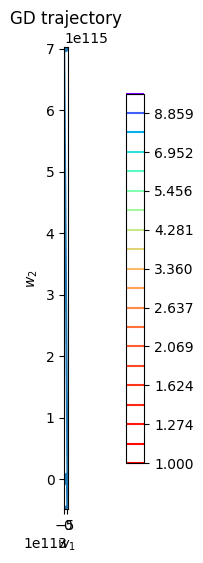

0.09796122448979593


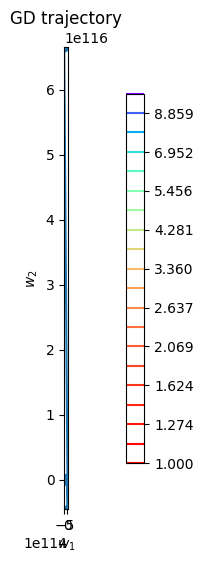

0.1


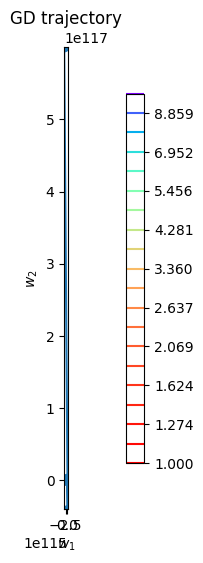

In [130]:
lr_list = np.linspace(
    start = 0.0001,
    stop = 0.1,
    num = 50
).astype(float)

for lr in lr_list:
    print(lr)
    w_list = gradient_descent(
        w_init = w_init,
        X = X, 
        y = y,
        loss = loss,
        lr = lr,
        n_iterations = 100,
    )
    plot_gd(
        w_list = w_list,
        X = X,
        y = y,
        loss = loss
    )

# Вывод

видим что лучший результат лежит между 0.0021387755102040816 и 0.006216326530612245

при увеличении lr амплитуда скачков становится очень большой, и получается что точка постоянно перелетает целевой минимум функционала ошибки, но если мы возьмем его ультра маленьким, то получится что мы слишком медленно идем, что будет очень ресурсоемко, так как вычислять градиент тяжеловато


Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [ ]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    if w_init.shape[0] != X.shape[1]:
        raise ValueError("invalid X or w_init param given")

    w_current = w_init
    weights_hist = [w_current]

    for i in range(n_iterations):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        x_batch = X[batch_indices]
        y_batch = y[batch_indices]
        w_current = w_current - lr * loss.calc_grad(
            X = x_batch,
            y = y_batch,
            w = w_current
        )
        weights_hist.append(w_current)
    return weights_hist

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

lr = 0.002
batch_size = 1


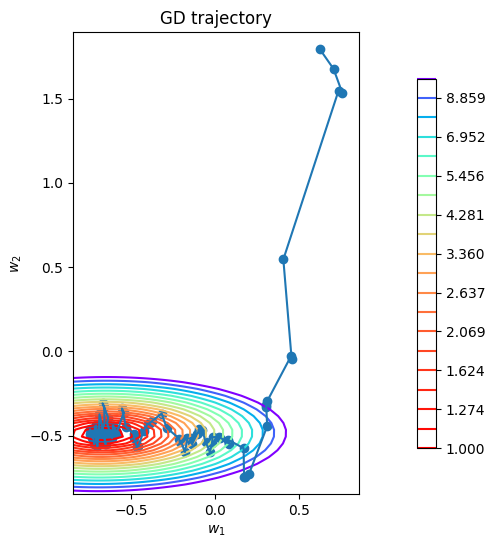

lr = 0.002
batch_size = 34


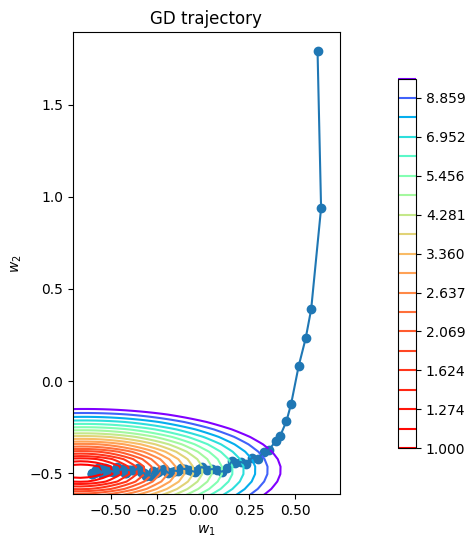

lr = 0.002
batch_size = 67


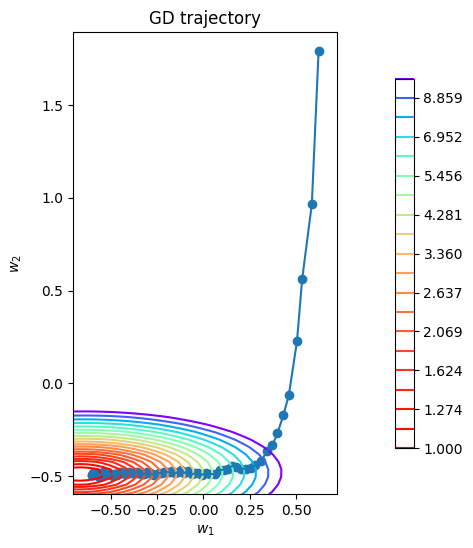

lr = 0.002
batch_size = 100


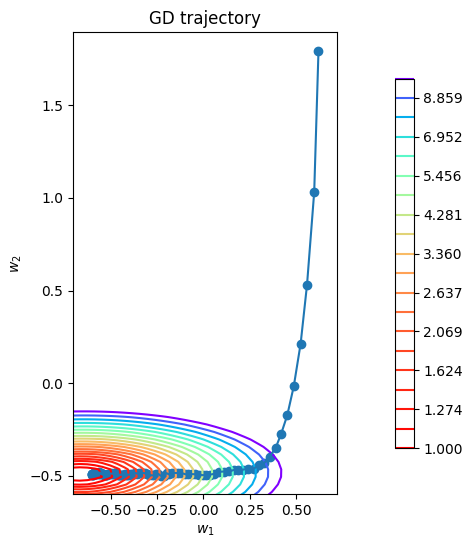

lr = 0.003333333333333333
batch_size = 1


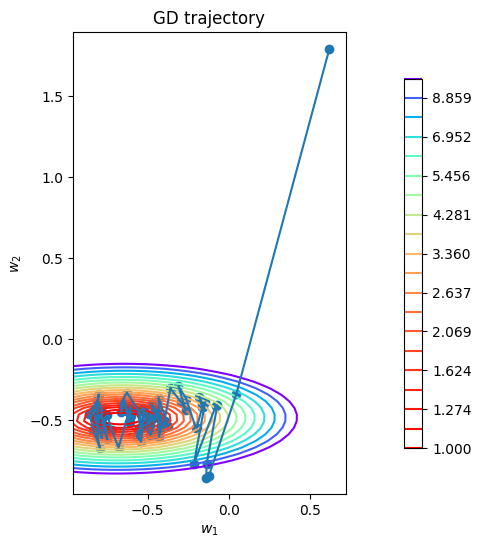

lr = 0.003333333333333333
batch_size = 34


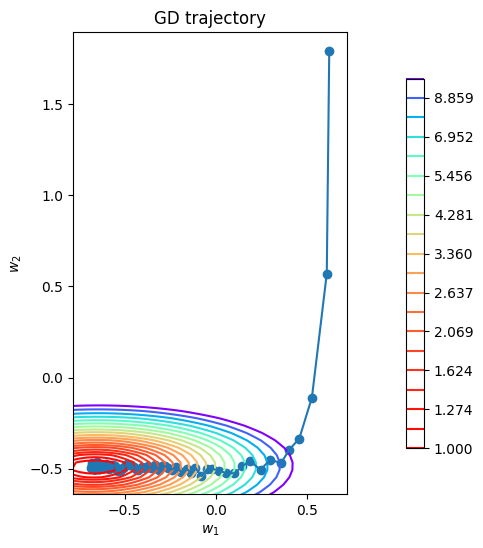

lr = 0.003333333333333333
batch_size = 67


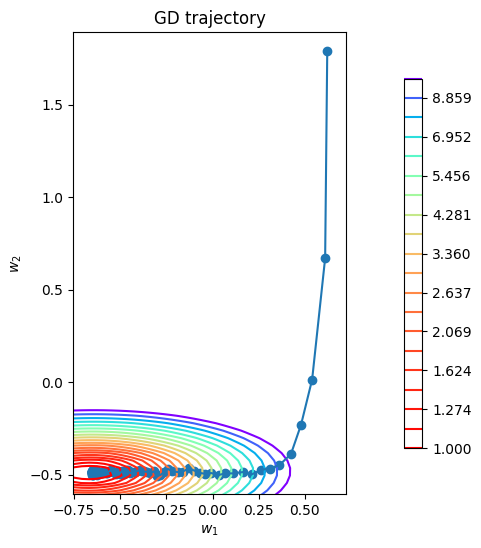

lr = 0.003333333333333333
batch_size = 100


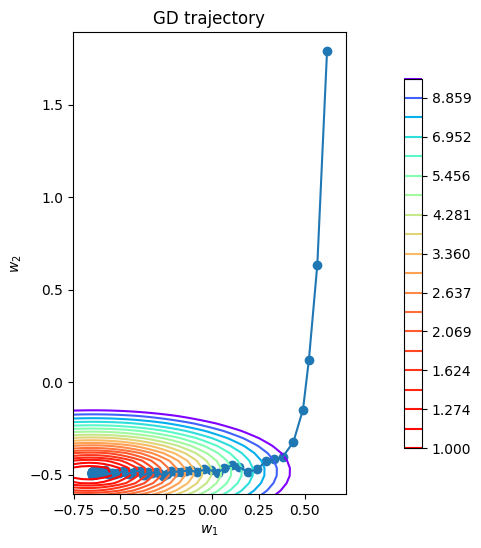

lr = 0.004666666666666666
batch_size = 1


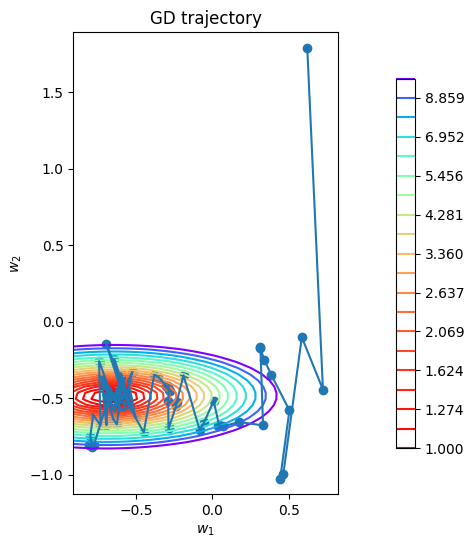

lr = 0.004666666666666666
batch_size = 34


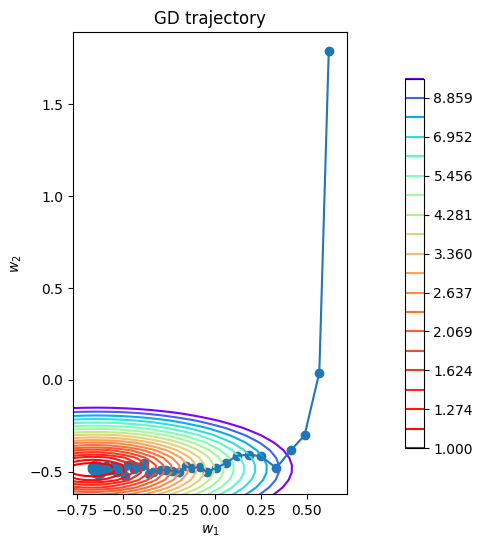

lr = 0.004666666666666666
batch_size = 67


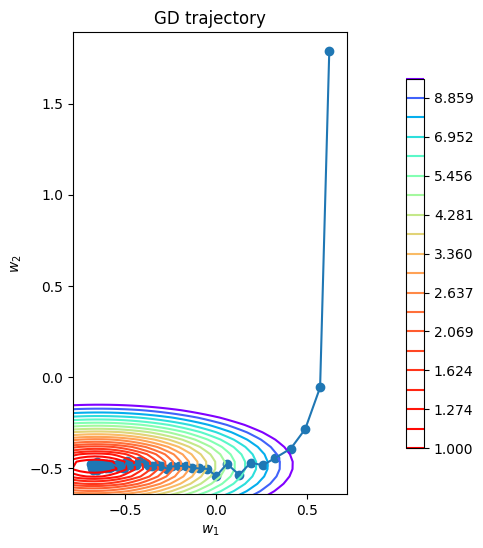

lr = 0.004666666666666666
batch_size = 100


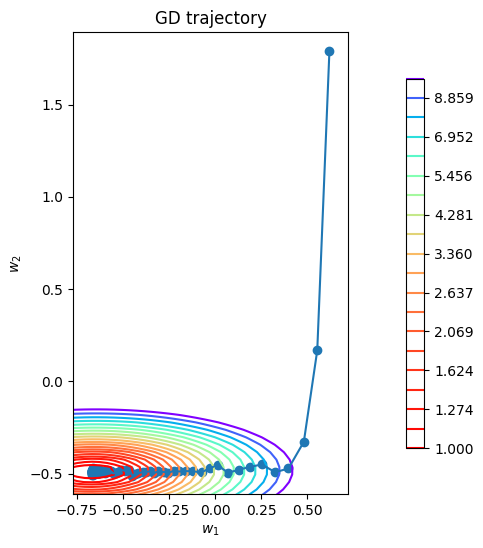

lr = 0.006
batch_size = 1


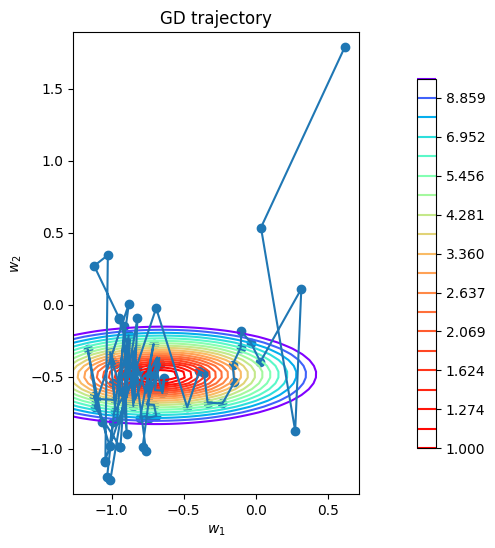

lr = 0.006
batch_size = 34


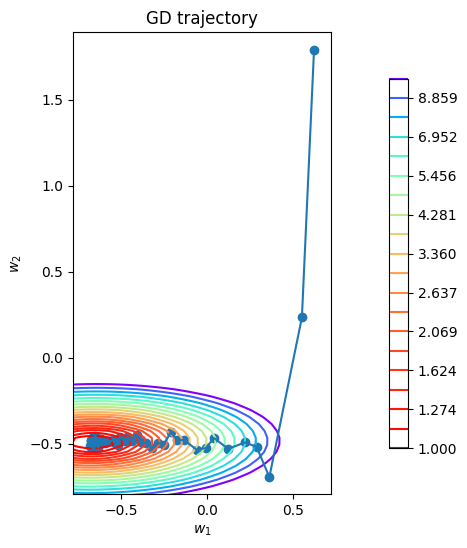

lr = 0.006
batch_size = 67


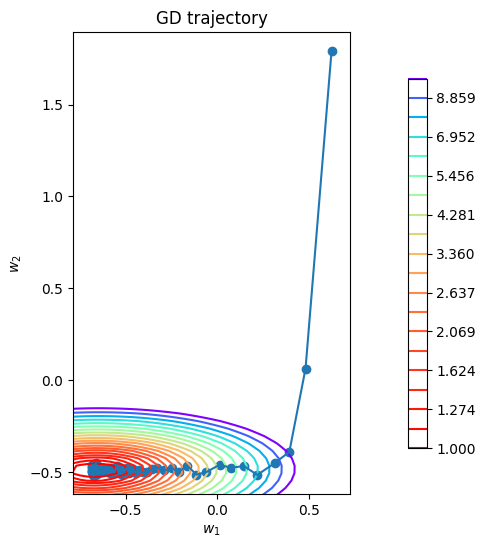

lr = 0.006
batch_size = 100


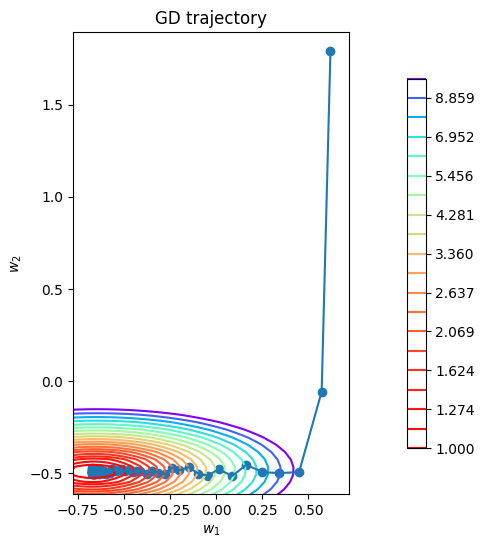

In [132]:
lr_min = 0.002
lr_max = 0.006
lr_num = 4

batch_size_min = 1
batch_size_max = 100
batch_size_num = 4

lr_list = np.linspace(
    start = lr_min,
    stop = lr_max,
    num = batch_size_num
).astype(float)

batch_list = np.linspace(
    start = batch_size_min,
    stop = batch_size_max,
    num = batch_size_num
).astype(int)

for lr in lr_list:
    for batch in batch_list:
        print(f"lr = {lr}")
        print(f"batch_size = {batch}")
        w_list = stochastic_gradient_descent(
            w_init = w_init,
            X = X, 
            y = y,
            loss = loss,
            lr = lr,
            n_iterations = 100,
            batch_size = batch
        )
        plot_gd(
            w_list = w_list,
            X = X,
            y = y,
            loss = loss
        )

# Промежуточный вывод
- Видим что когда у нас Batch size большой то спуск сильно виляет
- Когда у нас большой lr его носит еще больше

Го посмотрим как влият batch_size при прочих равных

lr = 0.003
batch_size = 1


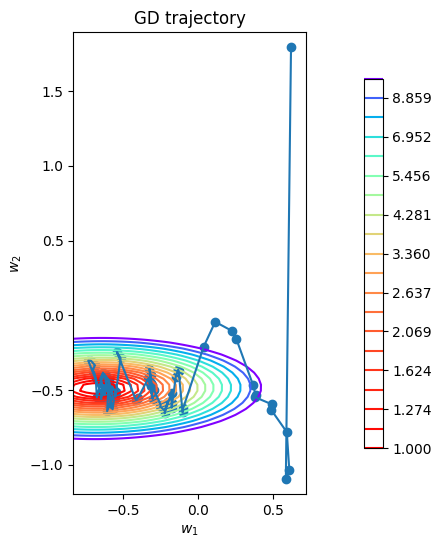

lr = 0.003
batch_size = 6


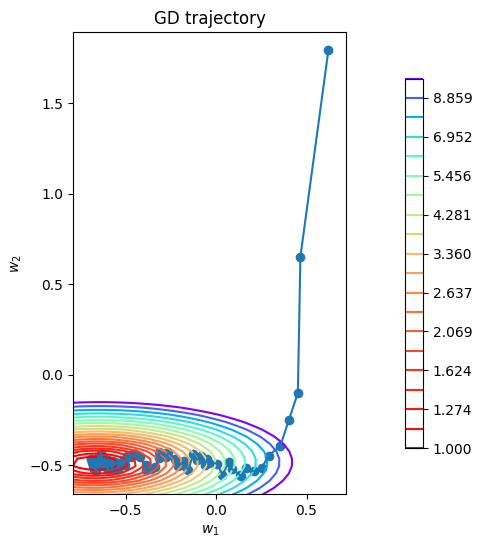

lr = 0.003
batch_size = 11


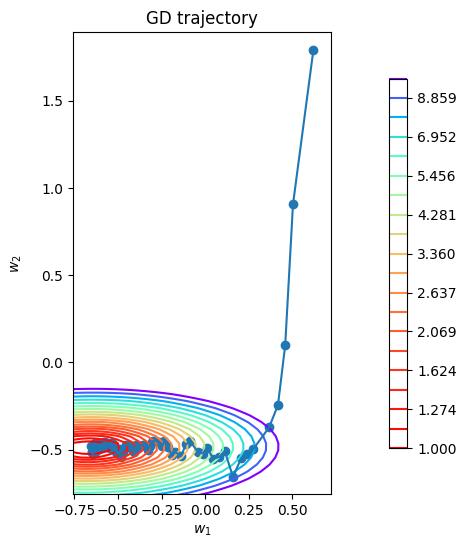

lr = 0.003
batch_size = 16


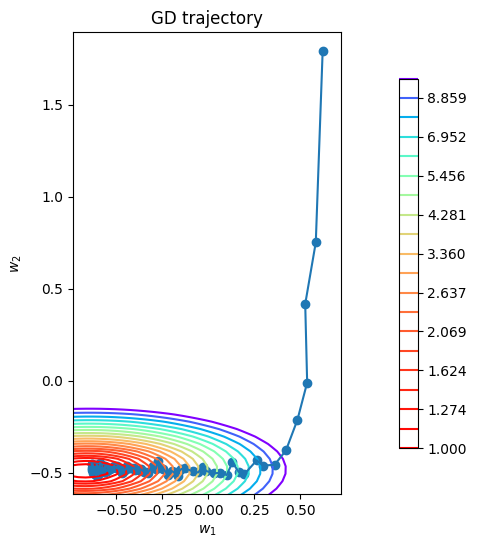

lr = 0.003
batch_size = 21


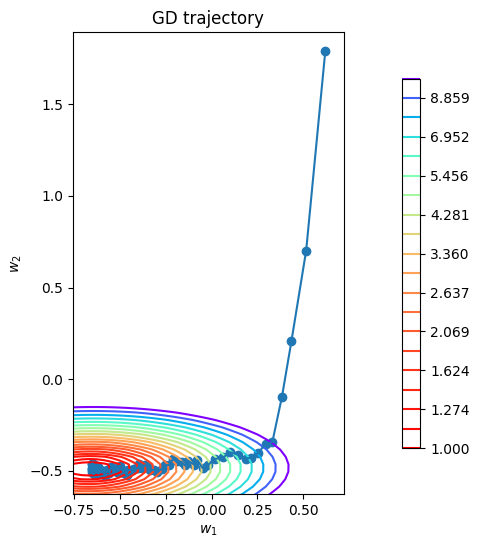

lr = 0.003
batch_size = 27


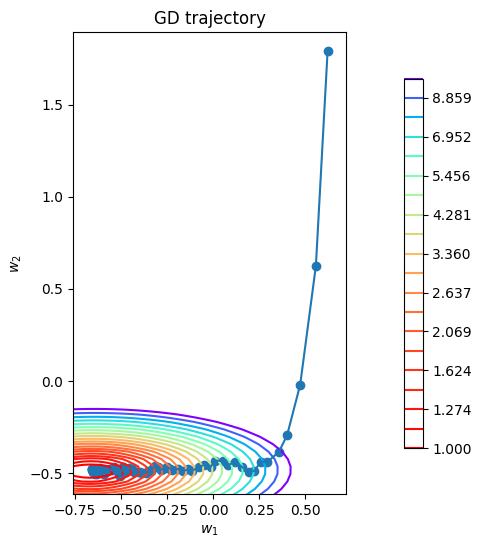

lr = 0.003
batch_size = 32


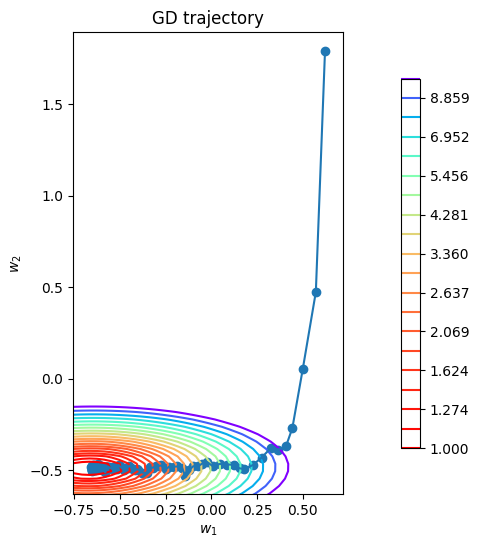

lr = 0.003
batch_size = 37


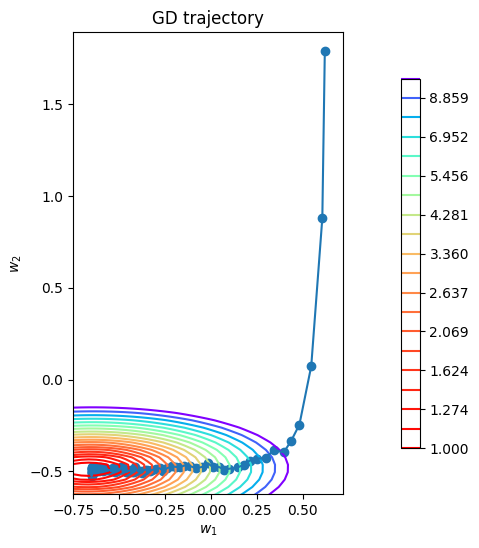

lr = 0.003
batch_size = 42


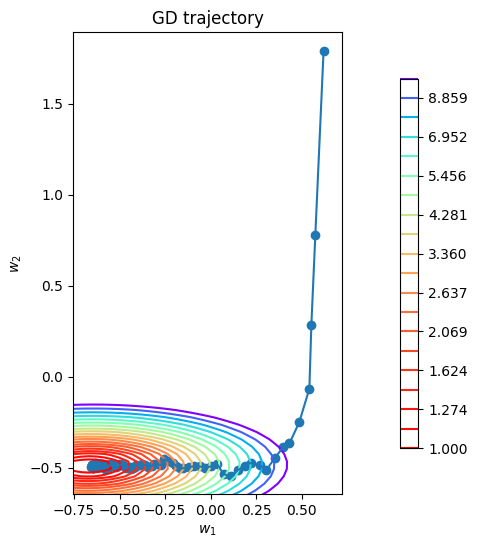

lr = 0.003
batch_size = 47


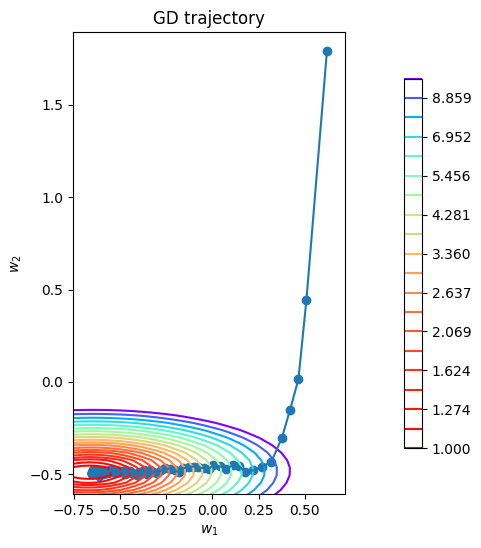

lr = 0.003
batch_size = 53


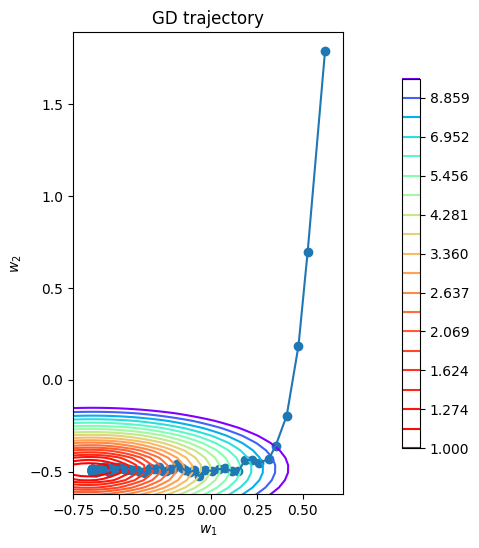

lr = 0.003
batch_size = 58


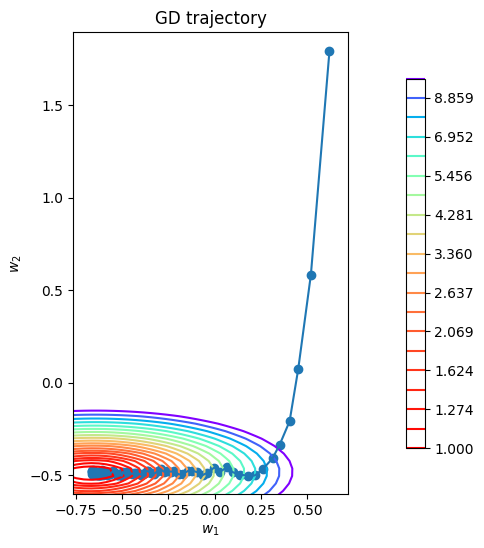

lr = 0.003
batch_size = 63


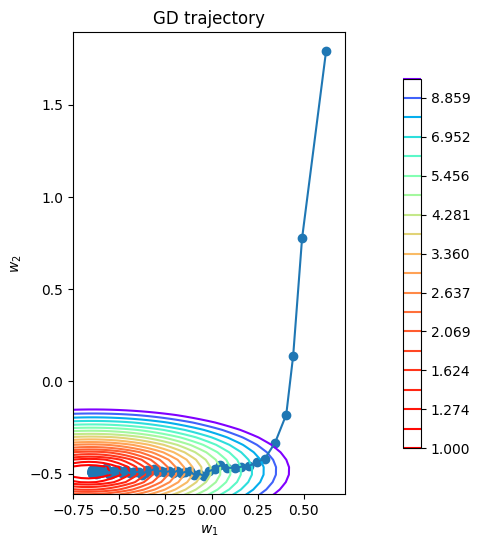

lr = 0.003
batch_size = 68


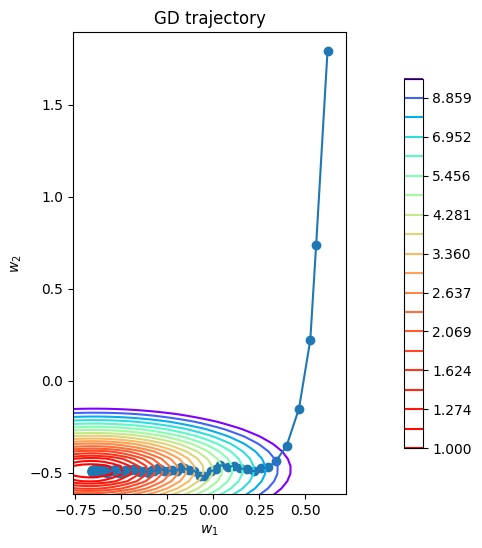

lr = 0.003
batch_size = 73


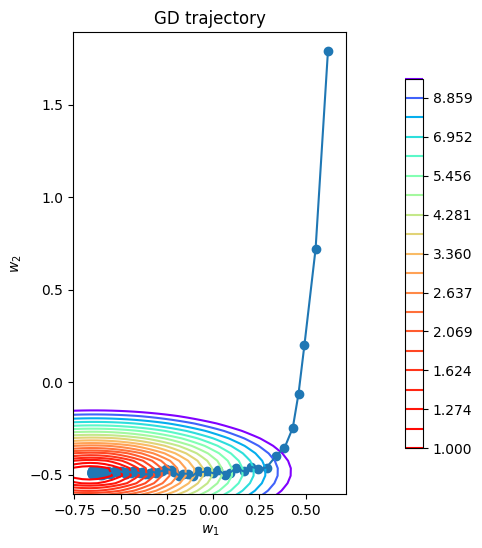

lr = 0.003
batch_size = 79


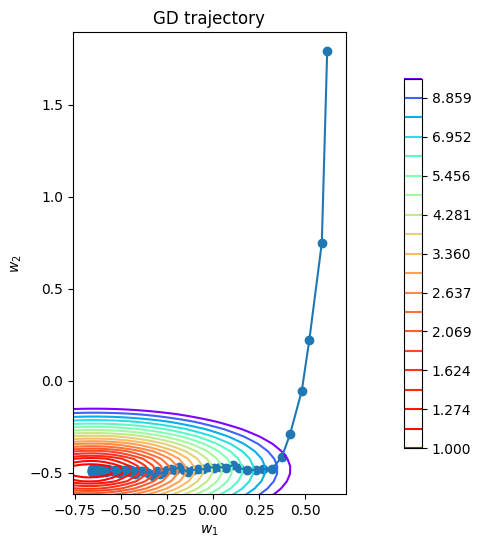

lr = 0.003
batch_size = 84


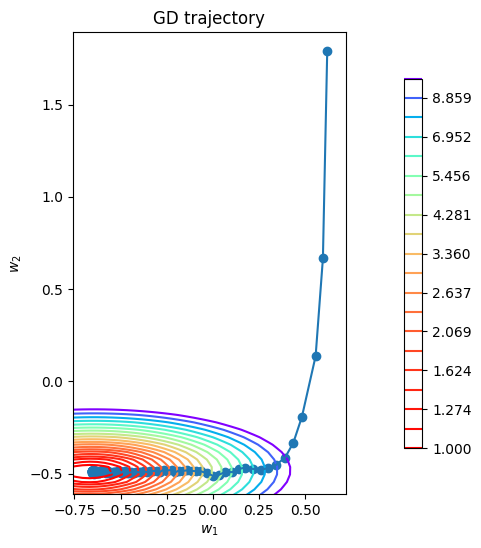

lr = 0.003
batch_size = 89


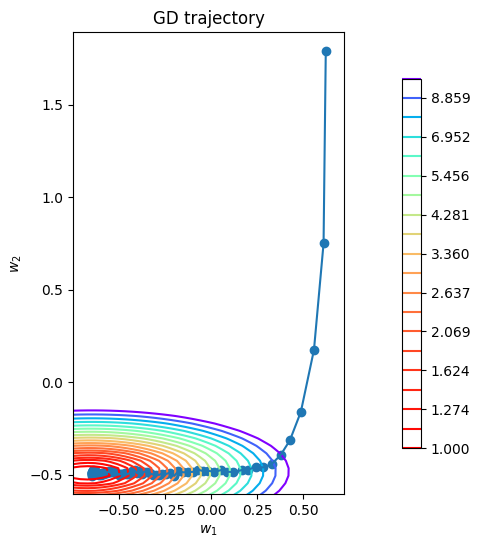

lr = 0.003
batch_size = 94


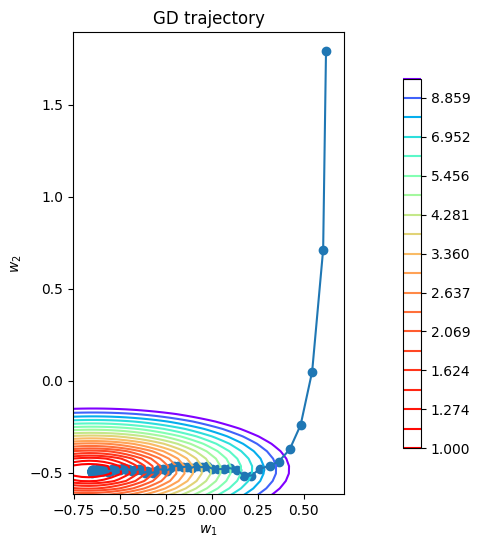

lr = 0.003
batch_size = 100


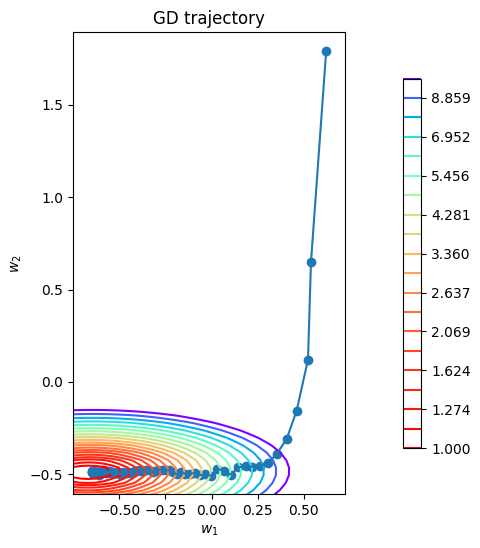

In [133]:
batch_size_min = 1
batch_size_max = 100
batch_size_num = 20


batch_list = np.linspace(
    start = batch_size_min,
    stop = batch_size_max,
    num = batch_size_num
).astype(int)

lr = 0.003

for batch in batch_list:
    print(f"lr = {lr}")
    print(f"batch_size = {batch}")
    w_list = stochastic_gradient_descent(
        w_init = w_init,
        X = X, 
        y = y,
        loss = loss,
        lr = lr,
        n_iterations = 100,
        batch_size = batch
    )
    plot_gd(
        w_list = w_list,
        X = X,
        y = y,
        loss = loss
    )

# Вывод
Видим что при устремлении batch_size к размеру выборки он из беспорядочного спуска стремится к обыкновенному градиентному спуску

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [ ]:
def count_theta(
    lamb,
    s0,
    t,
    p
):
    return lamb * ((s0) / (s0 + t))**p


def stochastic_gradient_descent_2(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    if w_init.shape[0] != X.shape[1]:
        raise ValueError("invalid X or w_init param given")

    w_current = w_init
    weights_hist = [w_current]

    for i in range(n_iterations):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        x_batch = X[batch_indices]
        y_batch = y[batch_indices]
        w_current = w_current - lr * loss.calc_grad(
            X = x_batch,
            y = y_batch,
            w = w_current
        )
        weights_hist.append(w_current)
        lr = count_theta(
            lamb=lr,
            s0=1,
            p=p,
            t=i
        )
    return weights_hist

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

lr = 0.01
batch_size = 10
p = 0.1


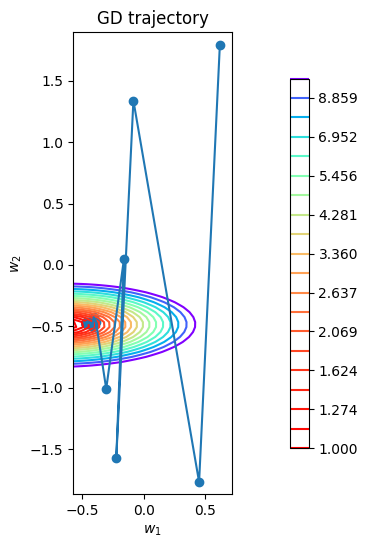

lr = 0.01
batch_size = 10
p = 0.12307692307692308


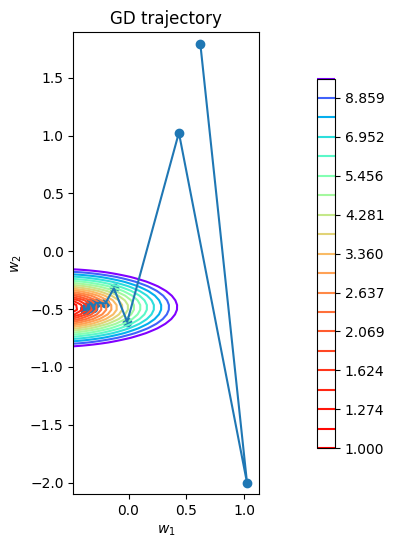

lr = 0.01
batch_size = 10
p = 0.14615384615384616


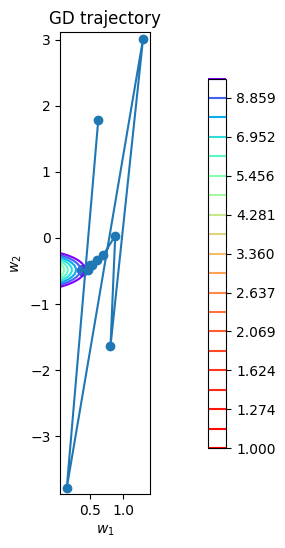

lr = 0.01
batch_size = 10
p = 0.16923076923076924


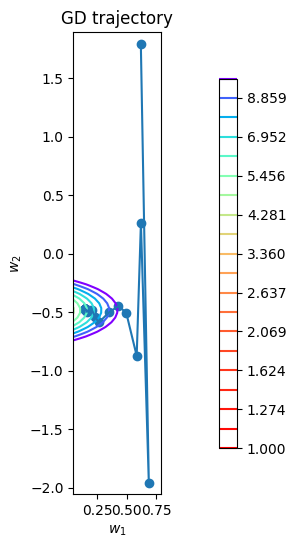

lr = 0.01
batch_size = 10
p = 0.19230769230769232


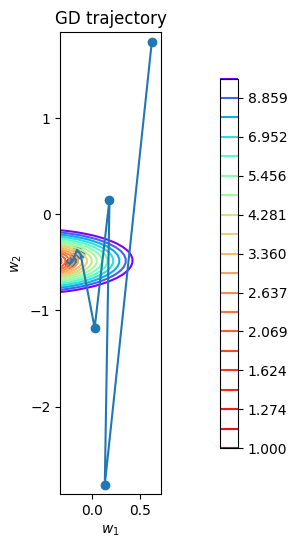

lr = 0.01
batch_size = 10
p = 0.2153846153846154


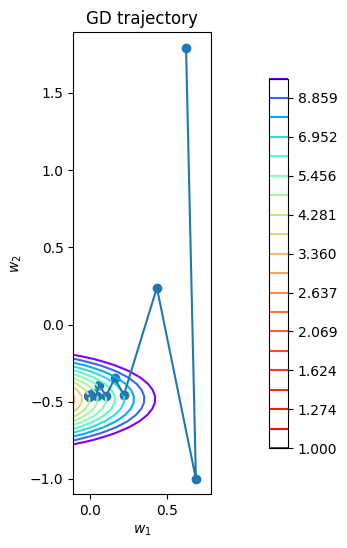

lr = 0.01
batch_size = 10
p = 0.23846153846153847


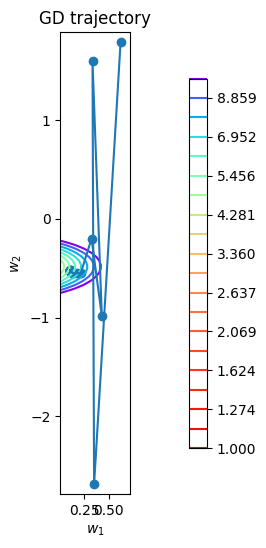

lr = 0.01
batch_size = 10
p = 0.26153846153846155


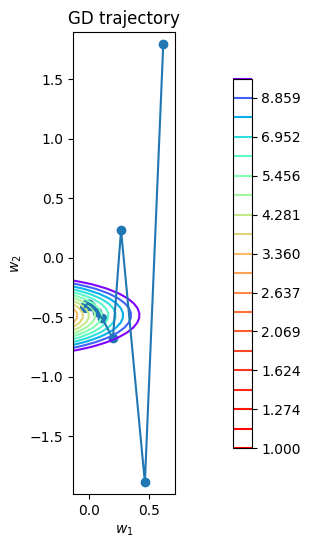

lr = 0.01
batch_size = 10
p = 0.2846153846153846


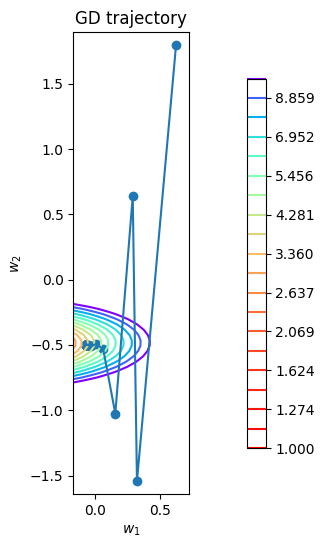

lr = 0.01
batch_size = 10
p = 0.3076923076923077


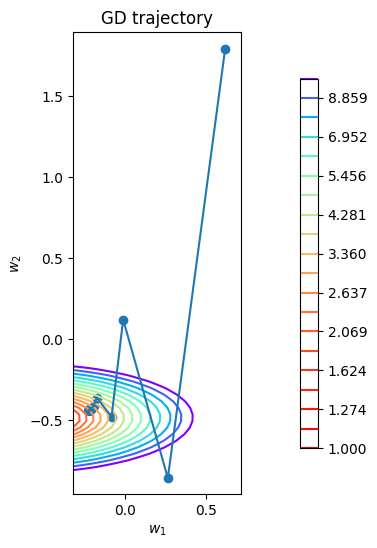

lr = 0.01
batch_size = 10
p = 0.3307692307692308


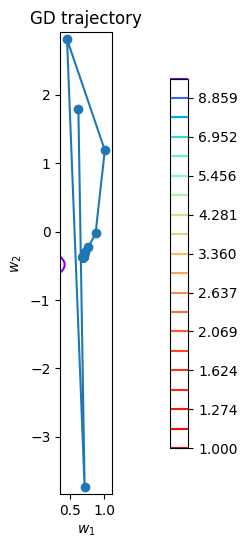

lr = 0.01
batch_size = 10
p = 0.3538461538461538


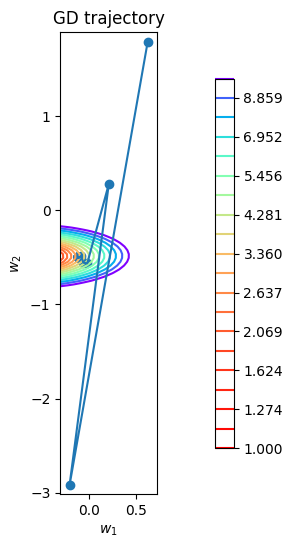

lr = 0.01
batch_size = 10
p = 0.3769230769230769


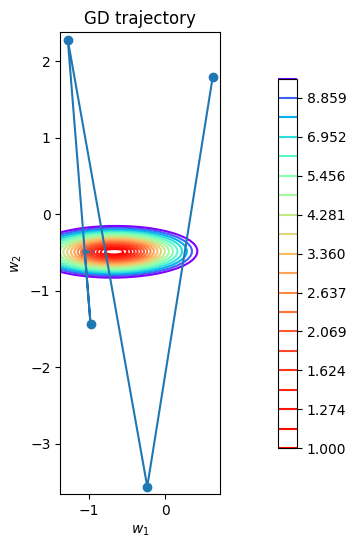

lr = 0.01
batch_size = 10
p = 0.4


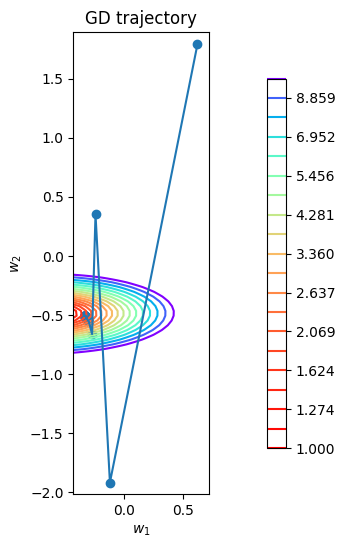

lr = 0.01
batch_size = 10
p = 0.42307692307692313


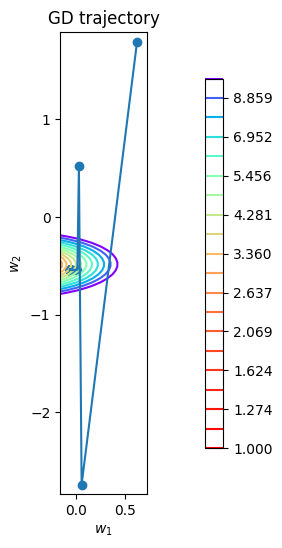

lr = 0.01
batch_size = 10
p = 0.4461538461538461


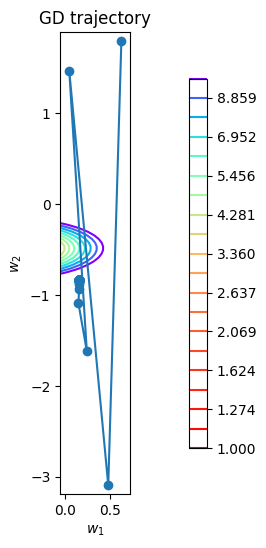

lr = 0.01
batch_size = 10
p = 0.46923076923076923


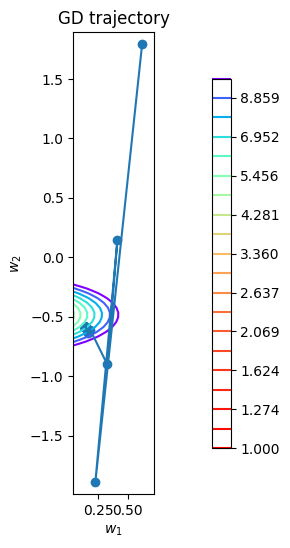

lr = 0.01
batch_size = 10
p = 0.49230769230769234


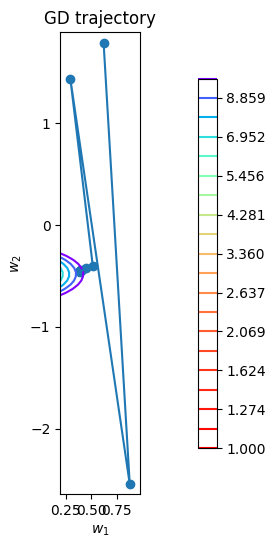

lr = 0.01
batch_size = 10
p = 0.5153846153846154


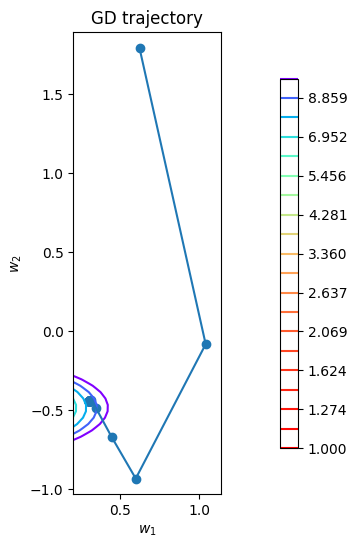

lr = 0.01
batch_size = 10
p = 0.5384615384615384


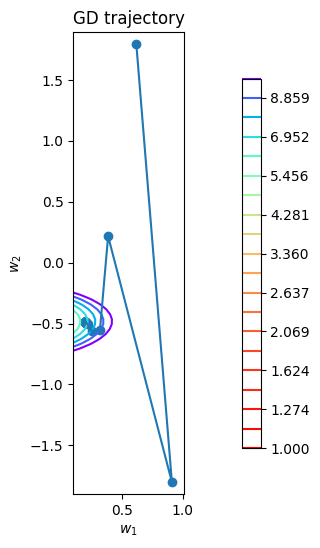

lr = 0.01
batch_size = 10
p = 0.5615384615384615


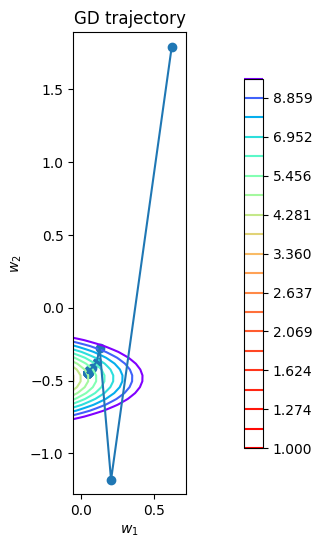

lr = 0.01
batch_size = 10
p = 0.5846153846153846


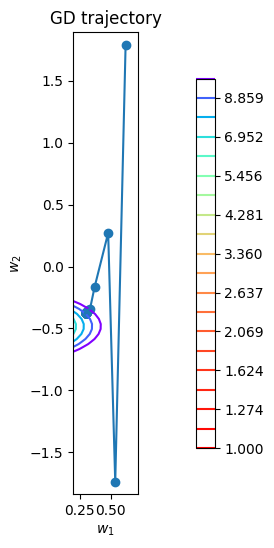

lr = 0.01
batch_size = 10
p = 0.6076923076923076


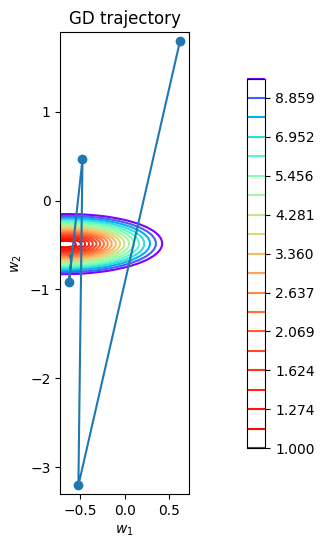

lr = 0.01
batch_size = 10
p = 0.6307692307692307


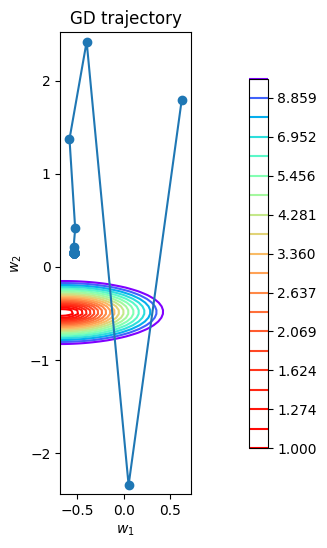

lr = 0.01
batch_size = 10
p = 0.6538461538461539


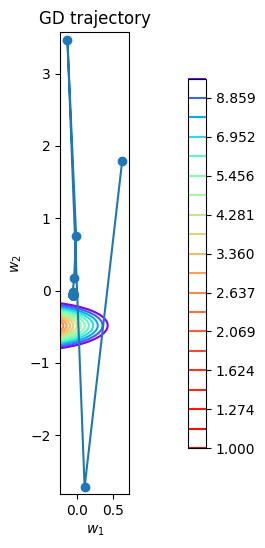

lr = 0.01
batch_size = 10
p = 0.676923076923077


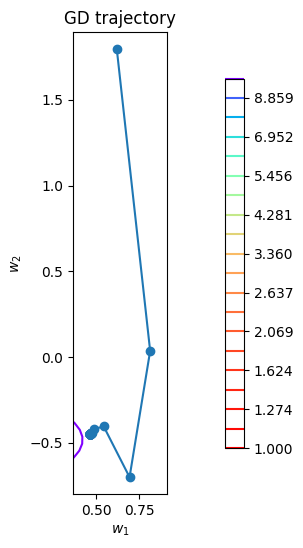

lr = 0.01
batch_size = 10
p = 0.7000000000000001


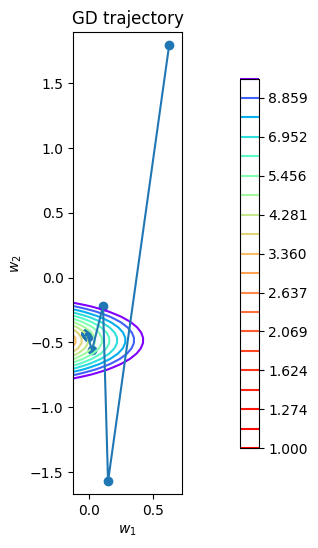

lr = 0.01
batch_size = 10
p = 0.7230769230769231


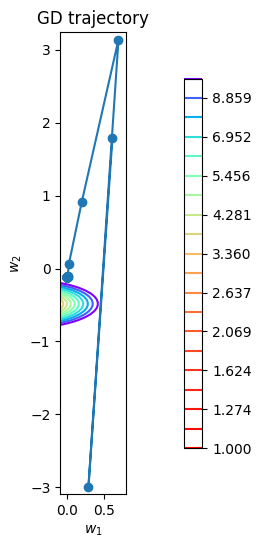

lr = 0.01
batch_size = 10
p = 0.7461538461538462


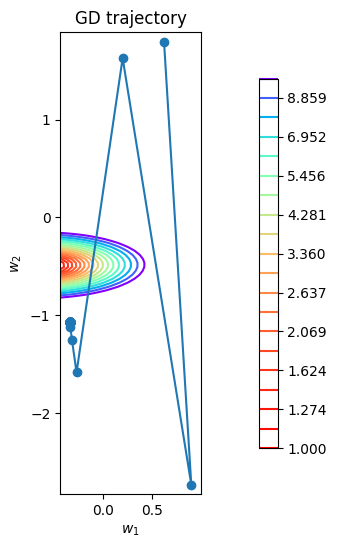

lr = 0.01
batch_size = 10
p = 0.7692307692307693


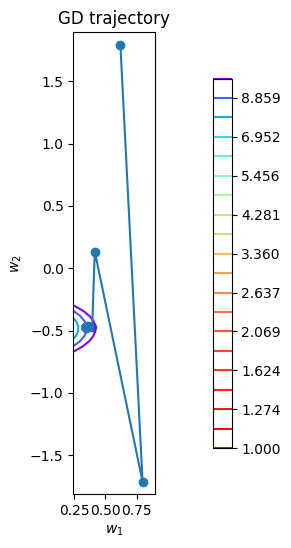

lr = 0.01
batch_size = 10
p = 0.7923076923076923


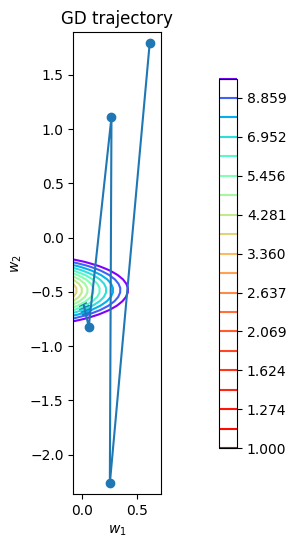

lr = 0.01
batch_size = 10
p = 0.8153846153846154


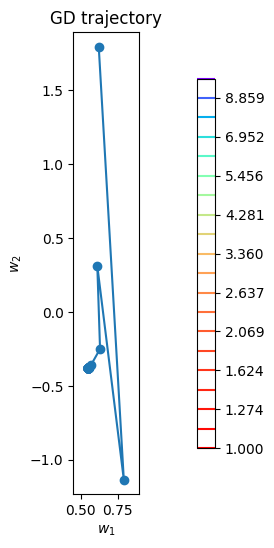

lr = 0.01
batch_size = 10
p = 0.8384615384615385


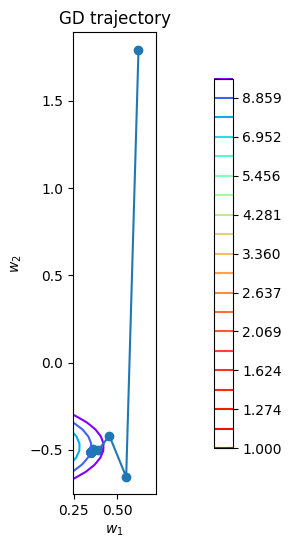

lr = 0.01
batch_size = 10
p = 0.8615384615384616


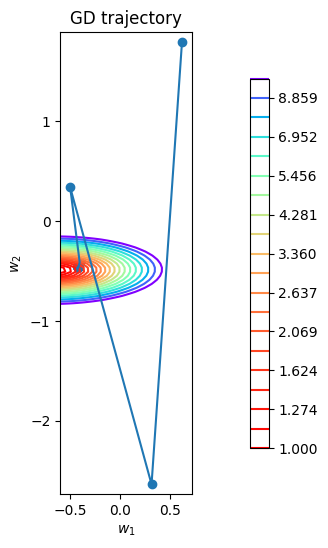

lr = 0.01
batch_size = 10
p = 0.8846153846153847


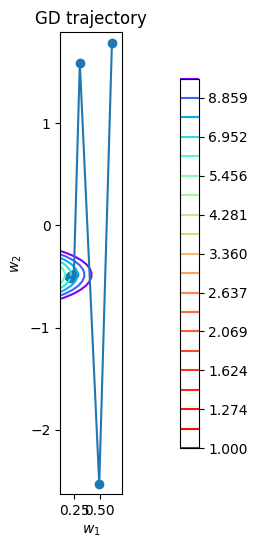

lr = 0.01
batch_size = 10
p = 0.9076923076923077


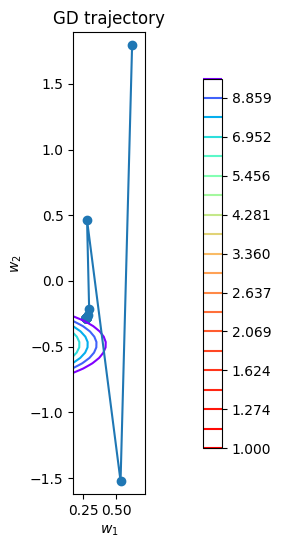

lr = 0.01
batch_size = 10
p = 0.9307692307692308


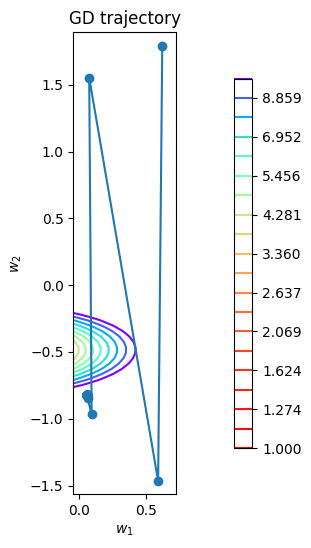

lr = 0.01
batch_size = 10
p = 0.9538461538461539


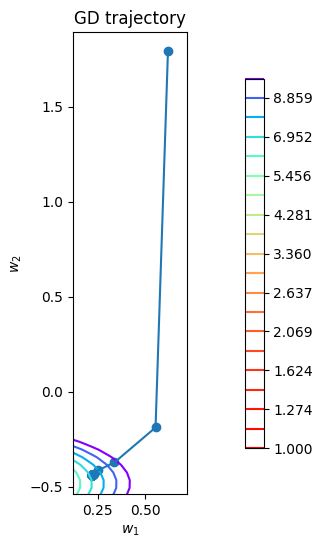

lr = 0.01
batch_size = 10
p = 0.9769230769230769


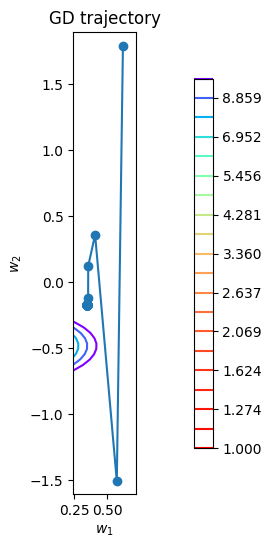

lr = 0.01
batch_size = 10
p = 1.0


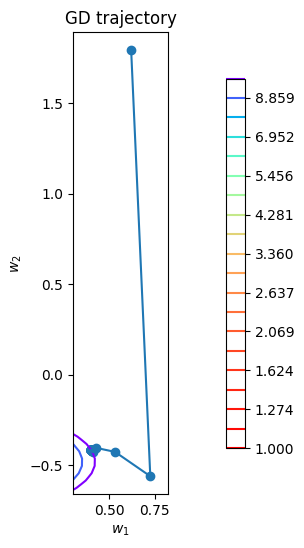

In [135]:
p_size_min = 0.1
p_size_max = 1
p_size_num = 40


p_list = np.linspace(
    start = p_size_min,
    stop = p_size_max,
    num = p_size_num
).astype(float)

lr = 0.01
batch = 10

for p in p_list:
    print(f"lr = {lr}")
    print(f"batch_size = {batch}")
    print(f"p = {p}")
    w_list = stochastic_gradient_descent_2(
        w_init = w_init,
        X = X, 
        y = y,
        loss = loss,
        lr = lr,
        n_iterations = 100,
        batch_size = batch,
        p = p
    )
    plot_gd(
        w_list = w_list,
        X = X,
        y = y,
        loss = loss
    )

# Вывод

При больших знаениях скачки очень сильные изначально, и получается так что сильный скачок далеко выкидывает нас от точки минимума, а потом мы не можем до нее дойти

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

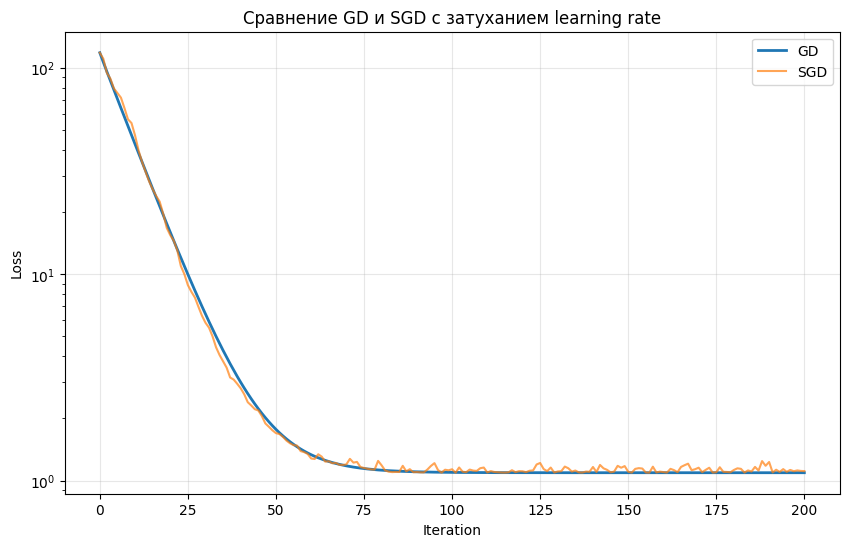

GD final loss: 1.091218
SGD final loss: 1.111026


In [155]:
loss = MSELoss()

n_iterations = 200
batch_size = 10
lr = 0.003
w_true = np.random.normal(size=(n_features,))
X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))


w_history_sgd = stochastic_gradient_descent(
    w_init=w_init,
    X=X,
    y=y,
    loss=loss,
    lr=lr,
    batch_size=batch_size,
    n_iterations=n_iterations
)

w_history_gd = gradient_descent(
    w_init=w_init,
    X=X,
    y=y,
    loss=loss,
    lr=lr,
    n_iterations=n_iterations
)


losses_gd = [loss.calc_loss(X, y, w) for w in w_history_gd]
losses_sgd = [loss.calc_loss(X, y, w) for w in w_history_sgd]


plt.figure(figsize=(10, 6))
plt.plot(losses_gd, label='GD', linewidth=2)
plt.plot(losses_sgd, label='SGD', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Сравнение GD и SGD с затуханием learning rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print(f"GD final loss: {losses_gd[-1]:.6f}")
print(f"SGD final loss: {losses_sgd[-1]:.6f}")

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [157]:
class LinearRegression:
    def __init__(
        self, 
        loss: BaseLoss, 
        lr: float = 0.1
    ) -> None:
        self.loss = loss
        self.lr = lr

    def fit(
        self, 
        X: np.ndarray, 
        y: np.ndarray
    ) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        w_init = np.zeros(X.shape[1])
        w_history = gradient_descent(
            w_init=w_init,
            X=X,
            y=y,
            loss=self.loss,
            lr=self.lr,
            n_iterations=1000
        )
        self.w = w_history[-1]
        return self

    def predict(
        self, 
        X: np.ndarray
    ) -> np.ndarray:
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        return X @ self.w

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [158]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [159]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [160]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

In [161]:
X_raw.shape

(201, 25)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [164]:
X_raw = X_raw.fillna(X_raw.mean(numeric_only=True))

numeric_cols = X_raw.select_dtypes(
    include=[np.number, int, float]
).columns

categorical_cols = X_raw.select_dtypes(
    include=['object']
).columns

X_numeric = MinMaxScaler().fit_transform(X_raw[numeric_cols])
X_categorical = OneHotEncoder(sparse_output=False).fit_transform(X_raw[categorical_cols])

X_processed = np.hstack([X_numeric, X_categorical])

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y, 
    test_size=0.2, 
    random_state=42
)

/var/folders/8g/hrr0dtn57lb04xhx37szq0k00000gn/T/ipykernel_73692/4166965256.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_raw.select_dtypes(


**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [167]:
linear_regression = linear_regression.fit(
    X = X_train,
    y = y_train
)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [ ]:
from sklearn.metrics import mean_squared_error

y_pred_train = linear_regression.predict(
    X = X_train,
)

y_pred_test = linear_regression.predict(
    X = X_test,
)

In [169]:
mean_squared_error(
    y_true = y_train,
    y_pred = y_pred_train
)

1744450.852500955

In [170]:
mean_squared_error(
    y_true = y_test,
    y_pred = y_pred_test
)

10145976.031738628

Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [ ]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        if X.shape[1] != w.shape[0]:
            raise ValueError("Invalid X and w parameters given")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Invalid y size given")
        pred = X @ w
        mse = np.mean((pred - y) ** 2)
        l2_penalty = self.coef * np.sum(w[:-1] ** 2)
        return mse + l2_penalty

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        if X.shape[1] != w.shape[0]:
            raise ValueError("Invalid X and w parameters given")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Invalid y size given")
        n = X.shape[0]
        pred = X @ w
        grad_mse = (2 / n) * np.transpose(X) @ (pred - y)
        grad_l2 = 2 * self.coef * w
        grad_l2[-1] = 0
        return grad_mse + grad_l2

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [180]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [192]:
lamb = np.linspace(
    start = 0.0,
    stop = 0.001,
    num = 100
)
totals = []
for l in lamb:
    linear_regression = LinearRegression(MSEL2Loss(l))
    linear_regression = linear_regression.fit(
        X = X_train,
        y = y_train
    )
    y_pred_train = linear_regression.predict(
        X = X_train,
    )

    y_pred_test = linear_regression.predict(
        X = X_test,
    )
    print(l)
    print(
        mean_squared_error(
            y_true = y_train,
            y_pred = y_pred_train
        )
    )
    print(
        mean_squared_error(
            y_true = y_test,
            y_pred = y_pred_test
        )
    )
    print("====================================")




0.0
1744450.852500955
10145976.031738628
1.0101010101010101e-05
1745031.6232574652
10147287.276220703
2.0202020202020203e-05
1745614.1867576917
10148608.265727911
3.0303030303030306e-05
1746198.5369431227
10149938.968724543
4.0404040404040405e-05
1746784.6677729413
10151279.353766264
5.0505050505050505e-05
1747372.5732239627
10152629.389499813
6.060606060606061e-05
1747962.2472905987
10153989.044662764
7.07070707070707e-05
1748553.6839847937
10155358.288083272
8.080808080808081e-05
1749146.877335981
10156737.08867976
9.090909090909092e-05
1749741.8213910304
10158125.415460724
0.00010101010101010101
1750338.510214199
10159523.237524454
0.00011111111111111112
1750936.9378870814
10160930.524058737
0.00012121212121212122
1751537.0985085592
10162347.244340641
0.00013131313131313133
1752138.9861947498
10163773.367736252
0.0001414141414141414
1752742.595078957
10165208.863700386
0.00015151515151515152
1753347.919311627
10166653.701776393
0.00016161616161616162
1753954.9530602894
10168107.8515

у меня получилось так, что регуляризация не дала значимого изменения в функционале ошибки
возможно стоило попробовать другой ее тип

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [194]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        if X.shape[1] != w.shape[0]:
            raise ValueError("Invalid X and w parameters given")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Invalid y size given")
        res = y - X @ w
        loss = np.where(
            np.abs(res) <= self.eps,
            0.5 * res ** 2,
            self.eps * (np.abs(res) - 0.5 * self.eps)
        )
        return np.mean(loss)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        if X.shape[1] != w.shape[0]:
            raise ValueError("Invalid X and w parameters given")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Invalid y size given")
        n = X.shape[0]
        res = y - X @ w
        mask = np.abs(res) <= self.eps
        gradient_res = np.where(
            mask, 
            -res, 
            -self.eps * np.sign(res)
        )
        return (1 / n) * np.transpose(X) @ gradient_res

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [197]:
lamb = np.linspace(
    start = 0.0,
    stop = 0.001,
    num = 100
)
totals = []
for eps in lamb:
    linear_regression = LinearRegression(HuberLoss(eps))
    linear_regression = linear_regression.fit(
        X = X_train,
        y = y_train
    )
    y_pred_train = linear_regression.predict(
        X = X_train,
    )

    y_pred_test = linear_regression.predict(
        X = X_test,
    )
    print(eps)
    print(
        mean_squared_error(
            y_true = y_train,
            y_pred = y_pred_train
        )
    )
    print(
        mean_squared_error(
            y_true = y_test,
            y_pred = y_pred_test
        )
    )
    print("====================================")




0.0
203723793.35625
368181638.24390244
1.0101010101010101e-05
203723563.40872863
368181362.0409822
2.0202020202020203e-05
203723333.46137756
368181085.8382263
3.0303030303030306e-05
203723103.5141968
368180809.6356352
4.0404040404040405e-05
203722873.56718642
368180533.4332086
5.0505050505050505e-05
203722643.62034625
368180257.23094636
6.060606060606061e-05
203722413.67367643
368179981.02884895
7.07070707070707e-05
203722183.72717696
368179704.826916
8.080808080808081e-05
203721953.78084776
368179428.6251475
9.090909090909092e-05
203721723.83468884
368179152.4235437
0.00010101010101010101
203721493.88870028
368178876.22210443
0.00011111111111111112
203721263.942882
368178600.0208297
0.00012121212121212122
203721033.99723405
368178323.81971955
0.00013131313131313133
203720804.05175644
368178047.6187739
0.0001414141414141414
203720574.10644907
368177771.41799283
0.00015151515151515152
203720344.161312
368177495.21737635
0.00016161616161616162
203720114.21634534
368177219.0169244
0.00017

# Вывод
Ошибка получилась хуже чем у двух предыдущих методов(((

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

Делаю на десктопном юпитере, так что вот ссыль))


https://disk.yandex.ru/i/mShPaiyyDxpwlg

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

In [199]:
class SimulatedAnnealingOptimizer:
    def __init__(self, loss, T0: float = 1.0, n_iter: int = 100, df: int = 3):
        self.loss = loss
        self.T0 = T0
        self.n_iter = n_iter
        self.df = df

    def _candidate(self, w: np.ndarray) -> np.ndarray:
        noise = np.random.standard_t(self.df, size=w.shape)
        return w + noise

    def _accept(self, curr_loss: float, new_loss: float, T: float) -> float:
        if new_loss < curr_loss:
            return 1.0
        return np.exp(-(new_loss - curr_loss) / T)

    def optimize(self, w_init: np.ndarray, X: np.ndarray, y: np.ndarray) -> list:
        try:
            best_w = w_init.copy()
            best_loss = self.loss.calc_loss(X, y, best_w)
            curr_w = best_w.copy()
            curr_loss = best_loss
            history = []
            for i in range(self.n_iter):
                T = self.T0 / (1 + i)
                new_w = self._candidate(curr_w)
                new_loss = self.loss.calc_loss(X, y, new_w)
                if new_loss < best_loss:
                    best_w = new_w.copy()
                    best_loss = new_loss
                if np.random.random() < self._accept(curr_loss, new_loss, T):
                    curr_w = new_w.copy()
                    curr_loss = new_loss
                history.append(curr_w.copy())
            history.append(best_w.copy())
            return history
        except Exception as e:
            raise RuntimeError(f"Optimization failed: {e}")

In [200]:
class AnnealingRegression:
    def __init__(self, loss, lr: float = 1.0, n_iterations: int = 100, df: int = 3):
        self.loss = loss
        self.lr = lr
        self.n_iterations = n_iterations
        self.df = df
        self.w = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        if X.shape[0] != y.shape[0]:
            raise ValueError("Invalid y size given")
        try:
            X = np.asarray(X)
            y = np.asarray(y)
            X = np.hstack([X, np.ones([X.shape[0], 1])])
            w_init = np.zeros(X.shape[1])
            optimizer = SimulatedAnnealingOptimizer(
                loss=self.loss,
                T0=self.lr,
                n_iter=self.n_iterations,
                df=self.df
            )
            history = optimizer.optimize(w_init, X, y)
            self.w = history[-1]
            return self
        except Exception as e:
            raise RuntimeError(f"Fitting failed: {e}")

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.w is None:
            raise ValueError("Model must be fitted first")
        X = np.asarray(X)
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        return X @ self.w

In [202]:
lamb = np.linspace(
    start = 0.0,
    stop = 0.001,
    num = 100
)
totals = []
for eps in lamb:
    linear_regression = AnnealingRegression(
        loss = MSELoss()
    )
    linear_regression = linear_regression.fit(
        X = X_train,
        y = y_train
    )
    y_pred_train = linear_regression.predict(
        X = X_train,
    )

    y_pred_test = linear_regression.predict(
        X = X_test,
    )
    print(eps)
    print(
        mean_squared_error(
            y_true = y_train,
            y_pred = y_pred_train
        )
    )
    print(
        mean_squared_error(
            y_true = y_test,
            y_pred = y_pred_test
        )
    )
    print("====================================")




0.0
197440777.60891995
360215903.6293136
1.0101010101010101e-05
198947184.92567855
362547161.1685871
2.0202020202020203e-05
198817682.00652546
362424423.2938657
3.0303030303030306e-05
198226271.86251155
361304283.04297394
4.0404040404040405e-05
198202811.1761331
361350035.5323579
5.0505050505050505e-05
197430906.61816686
360274857.976949
6.060606060606061e-05
198606061.26526052
361403299.526685
7.07070707070707e-05
198602102.821226
361613764.0055609
8.080808080808081e-05
200726936.74385342
364505902.9365839
9.090909090909092e-05
197764322.77444053
360705342.23537606
0.00010101010101010101
198552772.3486514
361918015.3516061
0.00011111111111111112
198642144.7654539
362073997.64556247
0.00012121212121212122
199587922.75518656
363174480.66574377
0.00013131313131313133
198841247.36777526
361900521.3842793
0.0001414141414141414
198867331.38027143
362387441.2750601
0.00015151515151515152
199498390.57519737
362947018.0697227
0.00016161616161616162
199418281.57124844
362798526.8892452
0.000171

# Вывод
Алгоритм показал себя ультраплохо в сравнении с обычной регрессией, это грустно